In [ ]:
# ============================================
# STUDENT WELLBEING SURVEY - STATISTICAL ANALYSIS
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

# ------------------------------------------------
# Load dataset
# ------------------------------------------------

# For CSV
df = pd.read_csv("Student_Wellbeing_Survey.csv")

# If your file is Excel instead, use:
# df = pd.read_excel("Student_Wellbeing_Survey.xlsx")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (600, 20)


In [ ]:
# ============================================
# 1. DATASET INSPECTION
# ============================================

print("\nFirst 5 rows:")
display(df.head())

print("\nLast 5 rows:")
display(df.tail())

print("\nDataset shape:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nBasic statistical summary:")
display(df.describe(include="all").T)


First 5 rows:


,Student_ID,Age,Faculty,Year_of_Study,City,Accommodation,Scholarship,Part_Time_Job,Internet_Quality,Preferred_Study_Space,Weekly_Study_Hours,Average_Sleep_Hours,Daily_Screen_Time_Hours,Exercise_Days_Per_Week,Commute_Time_Minutes,Stress_Score,Academic_Readiness_Score,Overall_Satisfaction,Monthly_Discretionary_Spending,Social_Activity_Hours_Per_Week
0,STU0001,21,Data Science,3,Bengaluru,Hostel,No,Yes,Good,Café,15.20,5.70,3.20,3,11.80,5.40,63.10,3.20,5131.00,7.80
1,STU0002,21,Data Science,4,Pune,Hostel,Yes,No,Poor,Library,17.60,7.70,3.50,4,20.30,2.10,74.20,3.80,3508.00,9.20
2,STU0003,22,Life Sciences,2,Chandigarh,Home,Yes,No,Poor,Home,18.90,6.40,2.80,1,15.00,5.20,77.30,4.00,4584.00,7.70
3,STU0004,18,Business,4,Bengaluru,Hostel,Yes,Yes,Average,Café,19.50,6.70,3.00,5,12.10,4.70,67.00,4.00,5456.00,5.30
4,STU0005,20,Business,3,Jammu,Shared Apartment,Yes,No,Good,Home,18.40,7.30,3.00,1,30.20,5.40,65.60,3.20,11732.00,15.90



Last 5 rows:


,Student_ID,Age,Faculty,Year_of_Study,City,Accommodation,Scholarship,Part_Time_Job,Internet_Quality,Preferred_Study_Space,Weekly_Study_Hours,Average_Sleep_Hours,Daily_Screen_Time_Hours,Exercise_Days_Per_Week,Commute_Time_Minutes,Stress_Score,Academic_Readiness_Score,Overall_Satisfaction,Monthly_Discretionary_Spending,Social_Activity_Hours_Per_Week
595,STU0596,20,Engineering,3,Hyderabad,PG,Yes,No,Good,Home,11.70,6.70,5.50,1,21.80,4.50,60.60,4.70,8669.00,11.10
596,STU0597,21,Life Sciences,2,Pune,Shared Apartment,No,No,Average,Department Lab,9.40,7.20,9.90,2,36.10,7.60,75.70,3.80,5169.00,8.00
597,STU0598,18,Data Science,1,Pune,Hostel,No,No,Good,Café,17.30,7.00,4.10,3,11.80,5.00,59.50,4.40,7524.00,14.40
598,STU0599,22,Engineering,3,Hyderabad,Home,No,No,Good,Home,7.90,7.80,1.90,3,44.90,1.80,65.00,4.40,2327.00,7.20
599,STU0600,21,Engineering,1,Jammu,Home,No,No,Average,Library,21.00,7.70,3.00,3,15.00,4.50,85.20,3.40,3236.00,4.70



Dataset shape:
(600, 20)

Column names:
['Student_ID', 'Age', 'Faculty', 'Year_of_Study', 'City', 'Accommodation', 'Scholarship', 'Part_Time_Job', 'Internet_Quality', 'Preferred_Study_Space', 'Weekly_Study_Hours', 'Average_Sleep_Hours', 'Daily_Screen_Time_Hours', 'Exercise_Days_Per_Week', 'Commute_Time_Minutes', 'Stress_Score', 'Academic_Readiness_Score', 'Overall_Satisfaction', 'Monthly_Discretionary_Spending', 'Social_Activity_Hours_Per_Week']

Data types:
Student_ID                         object
Age                                 int64
Faculty                            object
Year_of_Study                       int64
City                               object
Accommodation                      object
Scholarship                        object
Part_Time_Job                      object
Internet_Quality                   object
Preferred_Study_Space              object
Weekly_Study_Hours                float64
Average_Sleep_Hours               float64
Daily_Screen_Time_Hours         

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Student_ID,600,600,STU0600,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,600.00,NaN,NaN,NaN,20.76,1.71,17.00,20.00,21.00,22.00,25.00
Faculty,600,5,Engineering,134,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year_of_Study,600.00,NaN,NaN,NaN,2.39,1.09,1.00,1.00,2.00,3.00,4.00
City,600,8,Delhi,91,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Accommodation,600,4,Home,219,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Scholarship,600,2,No,416,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Part_Time_Job,600,2,No,448,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Internet_Quality,600,4,Good,296,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Preferred_Study_Space,600,4,Home,304,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# ============================================
# 2. MEASURES OF CENTRAL TENDENCY
# ============================================

variables = [
    "Weekly_Study_Hours",
    "Average_Sleep_Hours",
    "Daily_Screen_Time_Hours",
    "Stress_Score",
    "Academic_Readiness_Score"
]

central_tendency = pd.DataFrame({
    "Mean": df[variables].mean(),
    "Median": df[variables].median(),
    "Mode": df[variables].mode().iloc[0]
})

print("Mean, Median and Mode:")
display(central_tendency)

Mean, Median and Mode:


,Mean,Median,Mode
Weekly_Study_Hours,15.69,15.40,13.10
Average_Sleep_Hours,7.00,7.00,7.00
Daily_Screen_Time_Hours,4.50,4.20,3.50
Stress_Score,4.46,4.50,4.70
Academic_Readiness_Score,71.77,71.65,71.10


In [ ]:
# ============================================
# 3. MEASURES OF DISPERSION
# ============================================

dispersion = pd.DataFrame(index=variables)

dispersion["Minimum"] = df[variables].min()
dispersion["Maximum"] = df[variables].max()
dispersion["Range"] = df[variables].max() - df[variables].min()

# ddof=1 gives sample variance and sample standard deviation
dispersion["Variance"] = df[variables].var()
dispersion["Standard Deviation"] = df[variables].std()

dispersion["Q1"] = df[variables].quantile(0.25)
dispersion["Q3"] = df[variables].quantile(0.75)
dispersion["IQR"] = dispersion["Q3"] - dispersion["Q1"]

print("Measures of Dispersion:")
display(dispersion)

Measures of Dispersion:


,Minimum,Maximum,Range,Variance,Standard Deviation,Q1,Q3,IQR
Weekly_Study_Hours,4.00,34.00,30.00,19.22,4.38,13.00,18.42,5.42
Average_Sleep_Hours,4.50,9.50,5.00,0.70,0.84,6.47,7.60,1.12
Daily_Screen_Time_Hours,1.20,12.40,11.20,3.47,1.86,3.20,5.40,2.20
Stress_Score,1.00,9.40,8.40,2.78,1.67,3.30,5.70,2.40
Academic_Readiness_Score,41.90,98.00,56.10,93.98,9.69,65.20,78.03,12.83


In [ ]:
# ============================================
# GREATEST VARIABILITY
# ============================================

greatest_sd_variable = dispersion["Standard Deviation"].idxmax()
greatest_iqr_variable = dispersion["IQR"].idxmax()

print("Variable with greatest standard deviation:")
print(greatest_sd_variable)

print("\nVariable with greatest IQR:")
print(greatest_iqr_variable)

# Coefficient of Variation
cv = (df[variables].std() / df[variables].mean()) * 100

cv_table = pd.DataFrame({
    "Mean": df[variables].mean(),
    "Standard Deviation": df[variables].std(),
    "Coefficient of Variation (%)": cv
})

print("\nCoefficient of Variation:")
display(cv_table)

print(
    "\nVariable with highest relative variability:",
    cv.idxmax()
)

Variable with greatest standard deviation:
Academic_Readiness_Score

Variable with greatest IQR:
Academic_Readiness_Score

Coefficient of Variation:


,Mean,Standard Deviation,Coefficient of Variation (%)
Weekly_Study_Hours,15.69,4.38,27.94
Average_Sleep_Hours,7.00,0.84,11.99
Daily_Screen_Time_Hours,4.50,1.86,41.36
Stress_Score,4.46,1.67,37.36
Academic_Readiness_Score,71.77,9.69,13.51



Variable with highest relative variability: Daily_Screen_Time_Hours


In [ ]:
# ============================================
# 4. OUTLIER DETECTION USING IQR
# ============================================

outlier_variables = [
    "Weekly_Study_Hours",
    "Daily_Screen_Time_Hours",
    "Commute_Time_Minutes",
    "Monthly_Discretionary_Spending"
]

outlier_results = {}

for col in outlier_variables:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ]

    outlier_results[col] = {
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Number of Outliers": len(outliers),
        "Outlier Values": outliers[col].tolist()
    }

outlier_summary = pd.DataFrame(outlier_results).T

print("IQR Outlier Analysis:")
display(outlier_summary)

IQR Outlier Analysis:


,Q1,Q3,IQR,Lower Bound,Upper Bound,Number of Outliers,Outlier Values
Weekly_Study_Hours,13.00,18.42,5.42,4.86,26.56,8,"[27.8, 26.6, 26.6, 4.0, 27.2, 34.0, 4.3, 27.2]"
Daily_Screen_Time_Hours,3.20,5.40,2.20,-0.10,8.70,18,"[9.8, 10.1, 11.8, 10.4, 12.4, 12.0, 10.6, 11.3..."
Commute_Time_Minutes,13.38,31.52,18.15,-13.85,58.75,4,"[65.2, 62.3, 72.5, 118.0]"
Monthly_Discretionary_Spending,4113.00,7808.50,3695.50,-1430.25,13351.75,20,"[28000.0, 16791.0, 13945.0, 14064.0, 31500.0, ..."


In [ ]:
# ============================================
# 4. OUTLIER DETECTION USING IQR
# ============================================

outlier_variables = [
    "Weekly_Study_Hours",
    "Daily_Screen_Time_Hours",
    "Commute_Time_Minutes",
    "Monthly_Discretionary_Spending"
]

outlier_results = {}

for col in outlier_variables:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ]

    outlier_results[col] = {
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Number of Outliers": len(outliers),
        "Outlier Values": outliers[col].tolist()
    }

outlier_summary = pd.DataFrame(outlier_results).T

print("IQR Outlier Analysis:")
display(outlier_summary)

IQR Outlier Analysis:


,Q1,Q3,IQR,Lower Bound,Upper Bound,Number of Outliers,Outlier Values
Weekly_Study_Hours,13.00,18.42,5.42,4.86,26.56,8,"[27.8, 26.6, 26.6, 4.0, 27.2, 34.0, 4.3, 27.2]"
Daily_Screen_Time_Hours,3.20,5.40,2.20,-0.10,8.70,18,"[9.8, 10.1, 11.8, 10.4, 12.4, 12.0, 10.6, 11.3..."
Commute_Time_Minutes,13.38,31.52,18.15,-13.85,58.75,4,"[65.2, 62.3, 72.5, 118.0]"
Monthly_Discretionary_Spending,4113.00,7808.50,3695.50,-1430.25,13351.75,20,"[28000.0, 16791.0, 13945.0, 14064.0, 31500.0, ..."


In [ ]:
# ============================================
# DISPLAY OUTLIER RECORDS
# ============================================

for col in outlier_variables:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower) |
        (df[col] > upper)
    ]

    print("\n================================")
    print("Variable:", col)
    print("================================")

    if len(outliers) == 0:
        print("No outliers detected.")
    else:
        display(outliers[["Student_ID", col]])


Variable: Weekly_Study_Hours


,Student_ID,Weekly_Study_Hours
130,STU0131,27.80
159,STU0160,26.60
276,STU0277,26.60
381,STU0382,4.00
460,STU0461,27.20
512,STU0513,34.00
542,STU0543,4.30
572,STU0573,27.20



Variable: Daily_Screen_Time_Hours


,Student_ID,Daily_Screen_Time_Hours
17,STU0018,9.80
85,STU0086,10.10
141,STU0142,11.80
172,STU0173,10.40
266,STU0267,12.40
303,STU0304,12.00
304,STU0305,10.60
332,STU0333,11.30
377,STU0378,9.10
390,STU0391,12.00



Variable: Commute_Time_Minutes


,Student_ID,Commute_Time_Minutes
18,STU0019,65.20
216,STU0217,62.30
374,STU0375,72.50
397,STU0398,118.00



Variable: Monthly_Discretionary_Spending


,Student_ID,Monthly_Discretionary_Spending
17,STU0018,28000.00
18,STU0019,16791.00
51,STU0052,13945.00
58,STU0059,14064.00
83,STU0084,31500.00
93,STU0094,19559.00
157,STU0158,14667.00
207,STU0208,14859.00
232,STU0233,13875.00
320,STU0321,14594.00


In [ ]:
# ============================================
# 5. BEFORE vs AFTER OUTLIER REMOVAL
# ============================================

column = "Weekly_Study_Hours"

Q1 = df[column].quantile(0.25)
Q3 = df[column].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Remove outliers
df_without_outliers = df[
    (df[column] >= lower_bound) &
    (df[column] <= upper_bound)
].copy()

comparison = pd.DataFrame({
    "Before Removing Outliers": [
        df[column].mean(),
        df[column].median()
    ],
    "After Removing Outliers": [
        df_without_outliers[column].mean(),
        df_without_outliers[column].median()
    ]
}, index=["Mean", "Median"])

print("Weekly Study Hours - Before vs After Outlier Removal:")
display(comparison)

print(f"Number of observations before: {len(df)}")
print(f"Number of observations after: {len(df_without_outliers)}")
print(f"Number of outliers removed: {len(df) - len(df_without_outliers)}")

Weekly Study Hours - Before vs After Outlier Removal:


,Before Removing Outliers,After Removing Outliers
Mean,15.69,15.60
Median,15.40,15.35


Number of observations before: 600
Number of observations after: 592
Number of outliers removed: 8


In [ ]:
mean_before = df[column].mean()
mean_after = df_without_outliers[column].mean()

median_before = df[column].median()
median_after = df_without_outliers[column].median()

print("\nInterpretation:")

if abs(mean_before - mean_after) > abs(median_before - median_after):
    print(
        "The mean changed more than the median after removing outliers, "
        "showing that extreme observations had a stronger effect on the mean."
    )
else:
    print(
        "The mean and median changed relatively little after removing outliers, "
        "suggesting that the detected outliers had limited influence on the center."
    )


Interpretation:
The mean changed more than the median after removing outliers, showing that extreme observations had a stronger effect on the mean.


In [ ]:
# ============================================
# 6. PROBABILITY ANALYSIS
# ============================================

# Event A:
# Student has a Part_Time_Job = Yes

A = df["Part_Time_Job"].astype(str).str.strip().str.lower() == "yes"

# Event B:
# Stress Score >= 7

B = df["Stress_Score"] >= 7

# Event C:
# Scholarship = Yes

C = df["Scholarship"].astype(str).str.strip().str.lower() == "yes"

# Event D:
# Exercise at least 3 days per week

D = df["Exercise_Days_Per_Week"] >= 3

n = len(df)

print("Total number of students:", n)

print("\nEvent counts:")
print("A - Part-time job:", A.sum())
print("B - Stress Score >= 7:", B.sum())
print("C - Scholarship:", C.sum())
print("D - Exercise >= 3 days/week:", D.sum())

Total number of students: 600

Event counts:
A - Part-time job: 152
B - Stress Score >= 7: 45
C - Scholarship: 184
D - Exercise >= 3 days/week: 356


In [ ]:
# ============================================
# BASIC PROBABILITIES
# ============================================

P_A = A.mean()
P_B = B.mean()
P_C = C.mean()
P_D = D.mean()

print(f"P(A) = {P_A:.4f} ({P_A*100:.2f}%)")
print(f"P(B) = {P_B:.4f} ({P_B*100:.2f}%)")
print(f"P(C) = {P_C:.4f} ({P_C*100:.2f}%)")
print(f"P(D) = {P_D:.4f} ({P_D*100:.2f}%)")

P(A) = 0.2533 (25.33%)
P(B) = 0.0750 (7.50%)
P(C) = 0.3067 (30.67%)
P(D) = 0.5933 (59.33%)


In [ ]:
# ============================================
# COMBINED PROBABILITIES
# ============================================

A_or_B = A | B
A_and_B = A & B

P_A_or_B = A_or_B.mean()
P_A_and_B = A_and_B.mean()

P_A_given_B = A_and_B.sum() / B.sum()
P_B_given_A = A_and_B.sum() / A.sum()

print(f"P(A or B) = {P_A_or_B:.4f} ({P_A_or_B*100:.2f}%)")
print(f"P(A and B) = {P_A_and_B:.4f} ({P_A_and_B*100:.2f}%)")
print(f"P(A | B) = {P_A_given_B:.4f} ({P_A_given_B*100:.2f}%)")
print(f"P(B | A) = {P_B_given_A:.4f} ({P_B_given_A*100:.2f}%)")

P(A or B) = 0.2767 (27.67%)
P(A and B) = 0.0517 (5.17%)
P(A | B) = 0.6889 (68.89%)
P(B | A) = 0.2039 (20.39%)


In [ ]:
# ============================================
# UNION FORMULA VERIFICATION
# ============================================

union_formula = P_A + P_B - P_A_and_B

print("Using formula:")
print("P(A ∪ B) = P(A) + P(B) - P(A ∩ B)")
print(
    f"= {P_A:.4f} + {P_B:.4f} - {P_A_and_B:.4f}"
)
print(f"= {union_formula:.4f}")

print("\nDirect calculation:", P_A_or_B)

Using formula:
P(A ∪ B) = P(A) + P(B) - P(A ∩ B)
= 0.2533 + 0.0750 - 0.0517
= 0.2767

Direct calculation: 0.27666666666666667


In [ ]:
# ============================================
# MUTUALLY EXCLUSIVE EVENTS
# ============================================

Year1 = df["Year_of_Study"] == 1
Year4 = df["Year_of_Study"] == 4

intersection_years = Year1 & Year4

print("Students in Year 1:", Year1.sum())
print("Students in Year 4:", Year4.sum())
print("Students simultaneously in Year 1 and Year 4:",
      intersection_years.sum())

if intersection_years.sum() == 0:
    print(
        "\nConclusion: Year 1 and Year 4 are mutually exclusive "
        "because P(Year 1 and Year 4) = 0."
    )
else:
    print(
        "\nConclusion: Year 1 and Year 4 are not mutually exclusive "
        "in this dataset."
    )

Students in Year 1: 164
Students in Year 4: 120
Students simultaneously in Year 1 and Year 4: 0

Conclusion: Year 1 and Year 4 are mutually exclusive because P(Year 1 and Year 4) = 0.


In [ ]:
# ============================================
# INDEPENDENCE TEST
# ============================================

product_probability = P_A * P_B

print("P(A and B):", round(P_A_and_B, 4))
print("P(A) × P(B):", round(product_probability, 4))

difference = abs(P_A_and_B - product_probability)

print("Absolute difference:", round(difference, 4))

# Small tolerance for floating-point comparison
if np.isclose(P_A_and_B, product_probability, atol=0.001):
    print(
        "\nConclusion: A and B appear to be independent because "
        "P(A and B) is approximately equal to P(A) × P(B)."
    )
else:
    print(
        "\nConclusion: A and B do not appear to be independent because "
        "P(A and B) differs from P(A) × P(B)."
    )

P(A and B): 0.0517
P(A) × P(B): 0.019
Absolute difference: 0.0327

Conclusion: A and B do not appear to be independent because P(A and B) differs from P(A) × P(B).


In [ ]:
# ============================================
# BAYES' THEOREM
# ============================================

not_A = ~A

P_not_A = not_A.mean()

# P(B | A)
P_B_given_A = (B & A).sum() / A.sum()

# P(B | not A)
P_B_given_not_A = (B & not_A).sum() / not_A.sum()

print(f"P(A) = {P_A:.4f}")
print(f"P(not A) = {P_not_A:.4f}")
print(f"P(B | A) = {P_B_given_A:.4f}")
print(f"P(B | not A) = {P_B_given_not_A:.4f}")

P(A) = 0.2533
P(not A) = 0.7467
P(B | A) = 0.2039
P(B | not A) = 0.0312


In [ ]:
# ============================================
# BAYES CALCULATION
# ============================================

bayes_numerator = P_B_given_A * P_A

bayes_denominator = (
    P_B_given_A * P_A
    + P_B_given_not_A * P_not_A
)

P_A_given_B_bayes = bayes_numerator / bayes_denominator

print("Bayes' Theorem:")
print("P(A|B) = [P(B|A) × P(A)] /")
print("         [P(B|A)P(A) + P(B|not A)P(not A)]")

print(
    f"\nP(A|B) = ({P_B_given_A:.4f} × {P_A:.4f}) / "
    f"[({P_B_given_A:.4f} × {P_A:.4f}) + "
    f"({P_B_given_not_A:.4f} × {P_not_A:.4f})]"
)

print(f"\nBayes P(A|B) = {P_A_given_B_bayes:.4f}")
print(f"Direct P(A|B) = {P_A_given_B:.4f}")

if np.isclose(P_A_given_B_bayes, P_A_given_B):
    print("\nVerification successful: Both calculations agree.")
else:
    print("\nSmall numerical difference may be due to rounding.")

Bayes' Theorem:
P(A|B) = [P(B|A) × P(A)] /
         [P(B|A)P(A) + P(B|not A)P(not A)]

P(A|B) = (0.2039 × 0.2533) / [(0.2039 × 0.2533) + (0.0312 × 0.7467)]

Bayes P(A|B) = 0.6889
Direct P(A|B) = 0.6889

Verification successful: Both calculations agree.


In [ ]:
# ============================================
# 7. NORMAL DISTRIBUTION ANALYSIS
# ============================================

readiness = df["Academic_Readiness_Score"]

mean_readiness = readiness.mean()
std_readiness = readiness.std()

print("Academic Readiness Score")
print("------------------------")
print(f"Mean = {mean_readiness:.4f}")
print(f"Standard Deviation = {std_readiness:.4f}")

Academic Readiness Score
------------------------
Mean = 71.7732
Standard Deviation = 9.6944


In [ ]:
# ============================================
# Z-SCORES
# ============================================

highest_index = readiness.idxmax()
lowest_index = readiness.idxmin()

highest_score = readiness.loc[highest_index]
lowest_score = readiness.loc[lowest_index]

highest_z = (highest_score - mean_readiness) / std_readiness
lowest_z = (lowest_score - mean_readiness) / std_readiness

print("Highest Academic Readiness Score")
print("---------------------------------")
print("Student ID:", df.loc[highest_index, "Student_ID"])
print("Score:", highest_score)
print("Z-score:", round(highest_z, 4))

print("\nLowest Academic Readiness Score")
print("--------------------------------")
print("Student ID:", df.loc[lowest_index, "Student_ID"])
print("Score:", lowest_score)
print("Z-score:", round(lowest_z, 4))

Highest Academic Readiness Score
---------------------------------
Student ID: STU0131
Score: 98.0
Z-score: 2.7054

Lowest Academic Readiness Score
--------------------------------
Student ID: STU0543
Score: 41.9
Z-score: -3.0815


In [ ]:
print("\nInterpretation:")

print(
    f"The highest-scoring student has a Z-score of {highest_z:.2f}, "
    f"meaning the score is approximately {abs(highest_z):.2f} "
    "standard deviations above the mean."
)

print(
    f"The lowest-scoring student has a Z-score of {lowest_z:.2f}, "
    f"meaning the score is approximately {abs(lowest_z):.2f} "
    "standard deviations below the mean."
)


Interpretation:
The highest-scoring student has a Z-score of 2.71, meaning the score is approximately 2.71 standard deviations above the mean.
The lowest-scoring student has a Z-score of -3.08, meaning the score is approximately 3.08 standard deviations below the mean.


In [ ]:
# ============================================
# EMPIRICAL RULE
# ============================================

print("68-95-99.7 EMPIRICAL RULE")
print("==========================")

print(
    f"Within 1 standard deviation: approximately 68% "
    f"of students are expected to have scores between "
    f"{mean_readiness - std_readiness:.2f} and "
    f"{mean_readiness + std_readiness:.2f}"
)

print(
    f"Within 2 standard deviations: approximately 95% "
    f"of students are expected to have scores between "
    f"{mean_readiness - 2*std_readiness:.2f} and "
    f"{mean_readiness + 2*std_readiness:.2f}"
)

print(
    f"Within 3 standard deviations: approximately 99.7% "
    f"of students are expected to have scores between "
    f"{mean_readiness - 3*std_readiness:.2f} and "
    f"{mean_readiness + 3*std_readiness:.2f}"
)

print("\nExpected percentages:")
print("Within ±1 SD:", "68%")
print("Within ±2 SD:", "95%")
print("Within ±3 SD:", "99.7%")

68-95-99.7 EMPIRICAL RULE
Within 1 standard deviation: approximately 68% of students are expected to have scores between 62.08 and 81.47
Within 2 standard deviations: approximately 95% of students are expected to have scores between 52.38 and 91.16
Within 3 standard deviations: approximately 99.7% of students are expected to have scores between 42.69 and 100.86

Expected percentages:
Within ±1 SD: 68%
Within ±2 SD: 95%
Within ±3 SD: 99.7%


In [ ]:
# ============================================
# ACTUAL PERCENTAGES VS EMPIRICAL RULE
# ============================================

within_1 = (
    (readiness >= mean_readiness - std_readiness) &
    (readiness <= mean_readiness + std_readiness)
)

within_2 = (
    (readiness >= mean_readiness - 2*std_readiness) &
    (readiness <= mean_readiness + 2*std_readiness)
)

within_3 = (
    (readiness >= mean_readiness - 3*std_readiness) &
    (readiness <= mean_readiness + 3*std_readiness)
)

actual_percentages = {
    "Within ±1 SD": within_1.mean() * 100,
    "Within ±2 SD": within_2.mean() * 100,
    "Within ±3 SD": within_3.mean() * 100
}

expected_percentages = {
    "Within ±1 SD": 68,
    "Within ±2 SD": 95,
    "Within ±3 SD": 99.7
}

normal_comparison = pd.DataFrame({
    "Actual Dataset (%)": actual_percentages,
    "Empirical Rule (%)": expected_percentages
})

display(normal_comparison)

,Actual Dataset (%),Empirical Rule (%)
Within ±1 SD,69.50,68.00
Within ±2 SD,95.17,95.00
Within ±3 SD,99.83,99.70


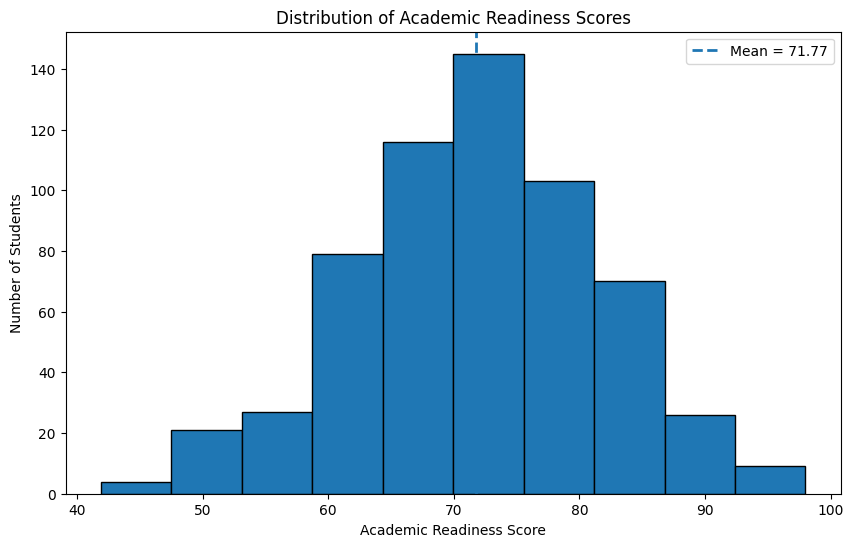

In [ ]:
# ============================================
# NORMAL DISTRIBUTION VISUALIZATION
# ============================================

plt.figure(figsize=(10, 6))

plt.hist(
    readiness,
    bins=10,
    edgecolor="black"
)

plt.axvline(
    mean_readiness,
    linestyle="--",
    linewidth=2,
    label=f"Mean = {mean_readiness:.2f}"
)

plt.xlabel("Academic Readiness Score")
plt.ylabel("Number of Students")
plt.title("Distribution of Academic Readiness Scores")
plt.legend()

plt.show()

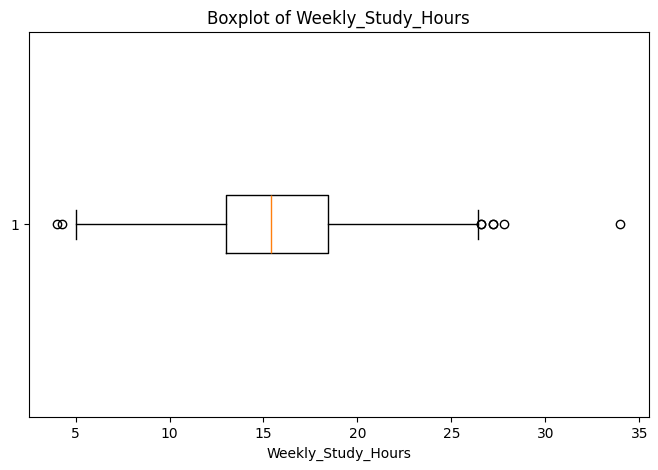

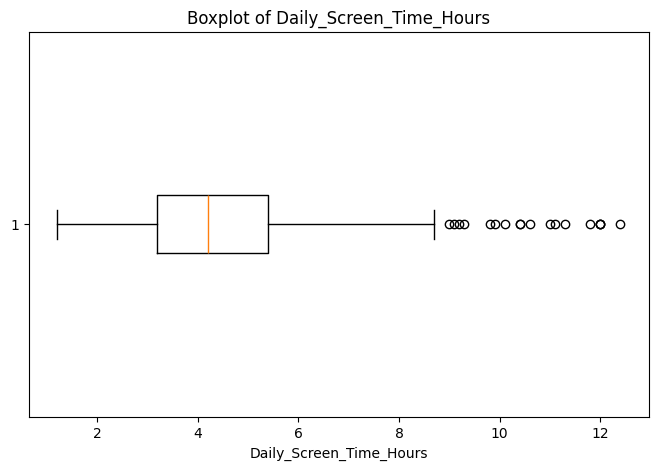

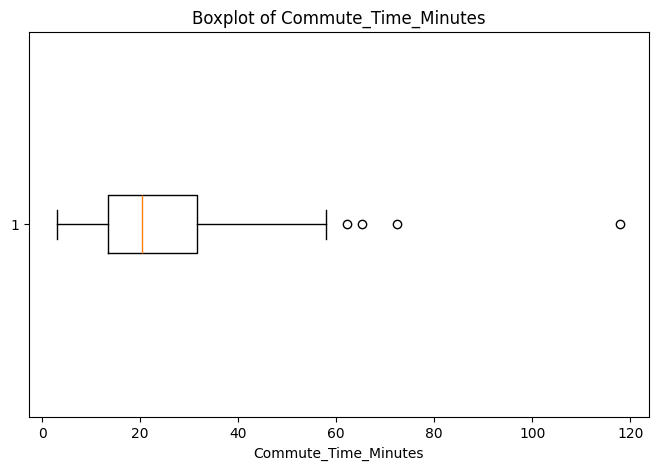

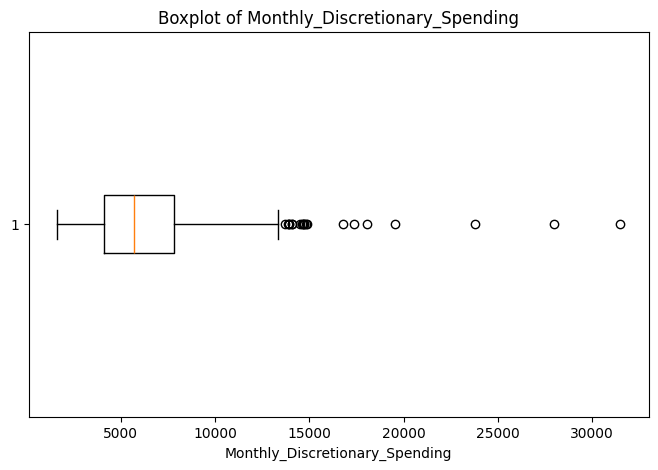

In [ ]:
# ============================================
# OUTLIER VISUALIZATION
# ============================================

for col in outlier_variables:

    plt.figure(figsize=(8, 5))

    plt.boxplot(
        df[col].dropna(),
        vert=False
    )

    plt.xlabel(col)
    plt.title(f"Boxplot of {col}")

    plt.show()

In [ ]:
# ============================================
# 8. FIVE STATISTICAL OBSERVATIONS
# ============================================

# Observation 1
print("1. CENTRAL TENDENCY")
print(
    f"The average Weekly Study Hours is "
    f"{df['Weekly_Study_Hours'].mean():.2f}, while the median is "
    f"{df['Weekly_Study_Hours'].median():.2f}. "
    "The comparison between mean and median provides an indication "
    "of the distribution's symmetry and the influence of extreme values."
)

# Observation 2
print("\n2. VARIABILITY")
print(
    f"Among the selected central numeric variables, "
    f"{greatest_sd_variable} has the highest standard deviation "
    f"({dispersion.loc[greatest_sd_variable, 'Standard Deviation']:.2f})."
)

# Observation 3
print("\n3. OUTLIERS")
for col in outlier_variables:

    count = outlier_summary.loc[col, "Number of Outliers"]

    print(
        f"{col}: {int(count)} outlier(s) were detected "
        "using the 1.5 × IQR rule."
    )

# Observation 4
print("\n4. PART-TIME JOB AND HIGH STRESS")
print(
    f"The probability that a student has a part-time job is "
    f"{P_A*100:.2f}%, while the probability of having a "
    f"Stress Score of at least 7 is {P_B*100:.2f}%."
)

# Observation 5
print("\n5. ACADEMIC READINESS")
print(
    f"The Academic Readiness Score has a mean of "
    f"{mean_readiness:.2f} and standard deviation of "
    f"{std_readiness:.2f}. "
    f"The highest score has a Z-score of {highest_z:.2f}, "
    f"while the lowest score has a Z-score of {lowest_z:.2f}."
)

1. CENTRAL TENDENCY
The average Weekly Study Hours is 15.69, while the median is 15.40. The comparison between mean and median provides an indication of the distribution's symmetry and the influence of extreme values.

2. VARIABILITY
Among the selected central numeric variables, Academic_Readiness_Score has the highest standard deviation (9.69).

3. OUTLIERS
Weekly_Study_Hours: 8 outlier(s) were detected using the 1.5 × IQR rule.
Daily_Screen_Time_Hours: 18 outlier(s) were detected using the 1.5 × IQR rule.
Commute_Time_Minutes: 4 outlier(s) were detected using the 1.5 × IQR rule.
Monthly_Discretionary_Spending: 20 outlier(s) were detected using the 1.5 × IQR rule.

4. PART-TIME JOB AND HIGH STRESS
The probability that a student has a part-time job is 25.33%, while the probability of having a Stress Score of at least 7 is 7.50%.

5. ACADEMIC READINESS
The Academic Readiness Score has a mean of 71.77 and standard deviation of 9.69. The highest score has a Z-score of 2.71, while the lowe

In [ ]:
# ============================================
# FINAL SUMMARY
# ============================================

summary = pd.DataFrame({
    "Statistic": [
        "P(A) - Part-time Job",
        "P(B) - Stress >= 7",
        "P(C) - Scholarship",
        "P(D) - Exercise >= 3 days",
        "P(A or B)",
        "P(A and B)",
        "P(A | B)",
        "P(B | A)",
        "P(A) × P(B)",
        "P(B | not A)",
        "Academic Readiness Mean",
        "Academic Readiness SD",
        "Highest Score Z",
        "Lowest Score Z"
    ],
    "Value": [
        P_A,
        P_B,
        P_C,
        P_D,
        P_A_or_B,
        P_A_and_B,
        P_A_given_B,
        P_B_given_A,
        product_probability,
        P_B_given_not_A,
        mean_readiness,
        std_readiness,
        highest_z,
        lowest_z
    ]
})

display(summary)

,Statistic,Value
0,P(A) - Part-time Job,0.25
1,P(B) - Stress >= 7,0.07
2,P(C) - Scholarship,0.31
3,P(D) - Exercise >= 3 days,0.59
4,P(A or B),0.28
5,P(A and B),0.05
6,P(A | B),0.69
7,P(B | A),0.20
8,P(A) × P(B),0.02
9,P(B | not A),0.03
